Some scratch cells for MAD-X to G4Beamline translation. I might organize this into something more formal later

# Common code

In [1]:
# Imports
from g4beam import *
from scan import *
from cpymad.madx import Madx
import scipy

In [2]:
# Get the single-cell data from MAD-X and reformat it to match the names we're using
madx = Madx()
madx.readtable(file="./madx/fodo_periodic.tfs")
madx_data = madx.table.get('twiss').selection(columns=["name", "keyword", "s", "betx", "alfx", "bety", "alfy"], rows='all').dframe(index="name")
madx_data = madx_data.rename(columns={
    "s": "z",
    "betx": "x_beta",
    "alfx": "x_alpha",
    "bety": "y_beta",
    "alfy": "y_alpha"
})
madx_data = madx_data.iloc[[0, 2, 3, 4, 6, 7, 8]]
madx_data


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Windows)     +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2025.04.03 17:22:33      +
  ++++++++++++++++++++++++++++++++++++++++++++



,name,keyword,z,x_beta,x_alpha,y_beta,y_alpha
fodo$start,fodo$start,marker,0.000,1.865010,-3.630975e-16,0.290822,-4.887851e-17
qf1h,qf1h,quadrupole,0.075,1.665851,2.555107e+00,0.344863,-7.473660e-01
drift_0,drift_0,drift,0.475,0.344862,7.473655e-01,1.665852,-2.555106e+00
qd1h,qd1h,quadrupole,0.550,0.290821,-1.207246e-16,1.865010,1.666149e-17
qd1h,qd1h,quadrupole,0.625,0.344862,-7.473655e-01,1.665852,2.555106e+00
drift_1,drift_1,drift,1.025,1.665851,-2.555107e+00,0.344863,7.473660e-01
qf1h,qf1h,quadrupole,1.100,1.865010,2.999069e-16,0.290822,3.621733e-16


In [3]:
# Function to process list of distributions into table
def df_list_to_table(particles_list):
    z_list = [df.z[0] for df in particles_list]
    res = list()
    for z, df in zip(z_list, particles_list):
        (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
        res.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit, len(df)])
    res = pd.DataFrame(res, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit", "N"])
    res.z *= 0.001
    return res

# Initial FODO data

Test getting data from the FODO g4bl file and graphing the distributions

In [4]:
# Generate a distribution for testing, matching the periodic segment of Ryan's MAD-X file

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)

In [35]:
# Run it using the new "multioutput" option
particles_after_list = run_g4beam(particles_before, "G4_QuadTest.g4bl", multioutput=["0", "1", "2", "3", "4"])

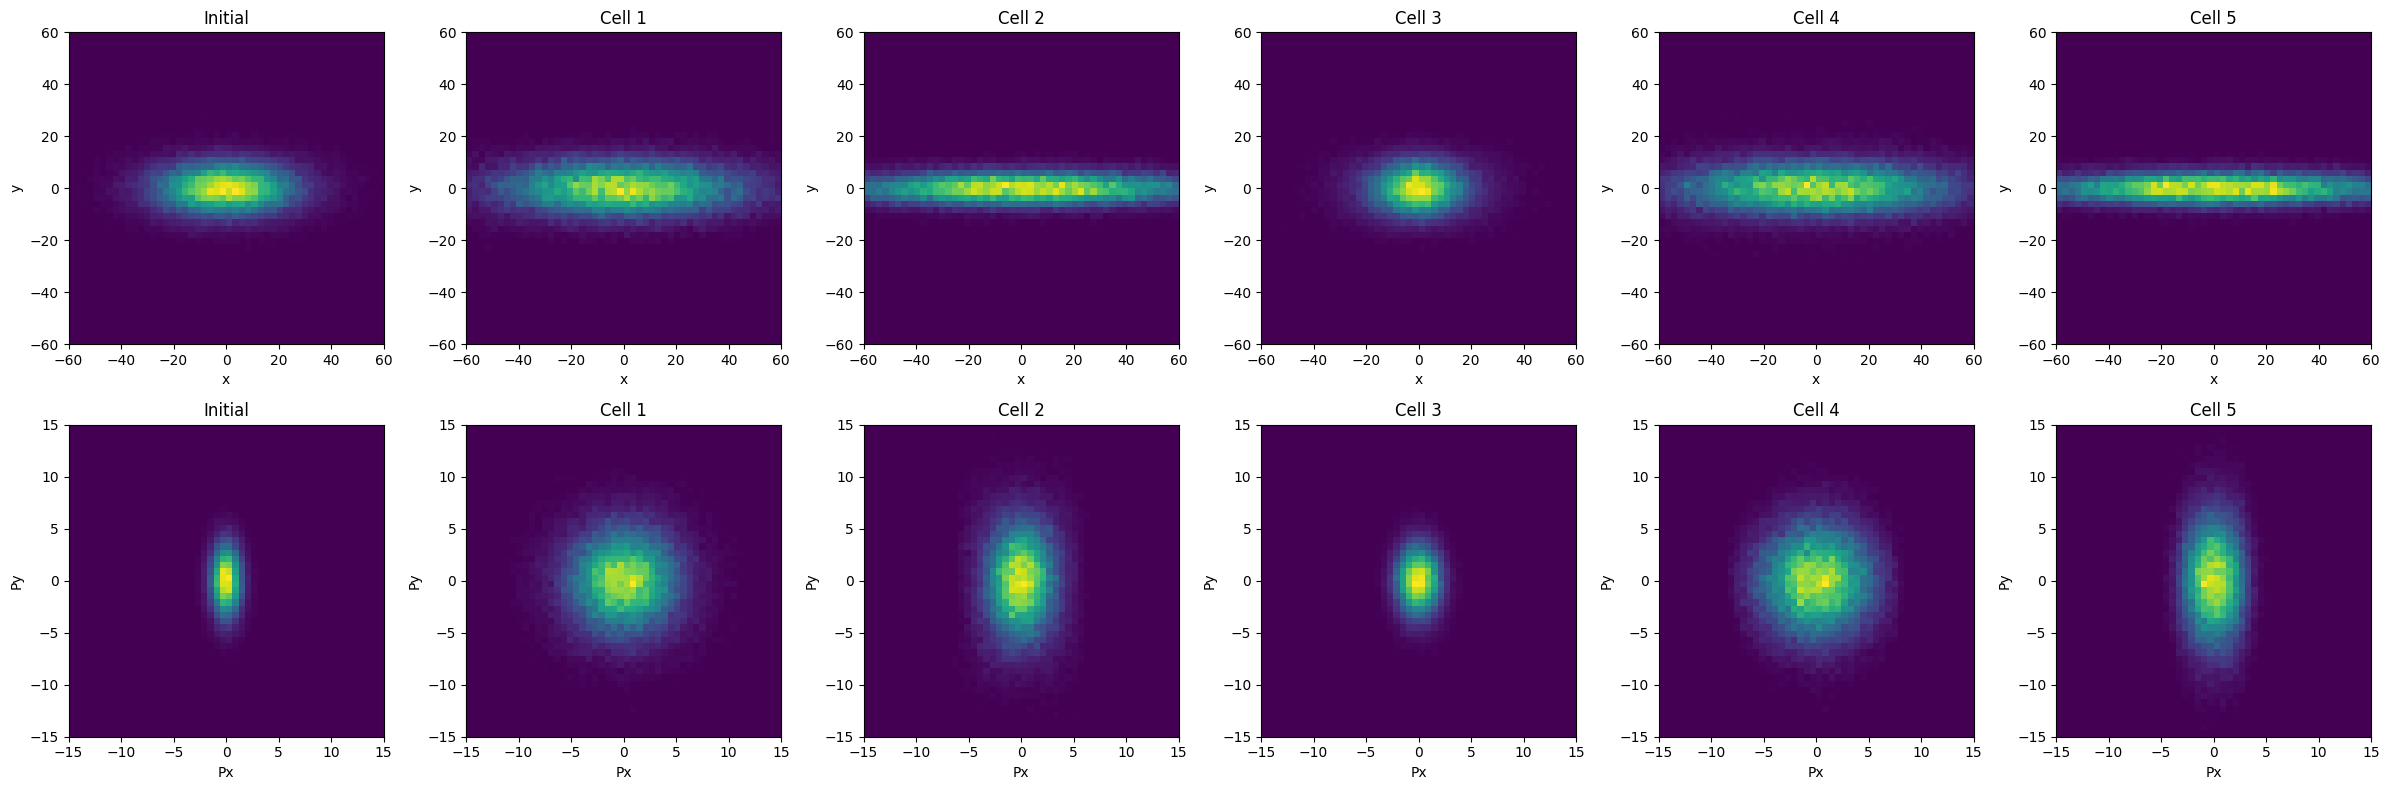

In [36]:
num_after = len(particles_after_list)
num_cols = num_after + 1  # One column for "before" and additional columns for each "after"
fig, axes = plt.subplots(2, num_cols, figsize=(4 * num_cols, 8))

x_range = [[-60, 60], [-60, 60]]
p_range = [[-15, 15], [-15, 15]]

# Plot "Before" data
axes[0, 0].hist2d(particles_before.x, particles_before.y, bins=50, range=x_range)
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].set_title("Initial")

axes[1, 0].hist2d(particles_before.Px, particles_before.Py, bins=50, range=p_range)
axes[1, 0].set_xlabel("Px")
axes[1, 0].set_ylabel("Py")
axes[1, 0].set_title("Initial")

# Plot each "After" dataset
for i, particles_after in enumerate(particles_after_list):
    col = i + 1  # Column index shifts right
    axes[0, col].hist2d(particles_after.x, particles_after.y, bins=50, range=x_range)
    axes[0, col].set_xlabel("x")
    axes[0, col].set_ylabel("y")
    axes[0, col].set_title(f"Cell {i+1}")

    axes[1, col].hist2d(particles_after.Px, particles_after.Py, bins=50, range=p_range)
    axes[1, col].set_xlabel("Px")
    axes[1, col].set_ylabel("Py")
    axes[1, col].set_title(f"Cell {i+1}")

plt.tight_layout()
plt.savefig("visuals/drift/test.png")


In [39]:
z_list = [0] + [df.z[0] for df in particles_after_list]
particles_list = [particles_before] + particles_after_list

data = list()
for z, df in zip(z_list, particles_list):
    (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
    data.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit])
data = pd.DataFrame(data, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit"])

In [40]:
data

,z,x_emit,x_beta,x_alpha,x_d,x_Dd,y_emit,y_beta,y_alpha,y_d,y_Dd,z_emit
0,0,0.145514,1.859872,-0.000467,0.002550,0.005699,0.143696,0.291166,0.001786,-0.003106,-0.013515,1.001291
1,1100,0.145543,5.360575,6.118135,0.015985,-0.016212,0.144142,0.307938,-1.093639,0.000027,0.017545,1.013630
2,2200,0.144129,9.808476,5.379989,-0.006224,0.002354,0.145172,0.106213,-0.158598,0.004698,0.001067,1.021536
3,3300,0.149585,1.098294,-0.406530,0.000642,0.002664,0.145639,0.317801,0.019679,-0.004591,-0.022064,1.000724
4,4400,0.154835,5.289202,5.549489,0.004312,-0.004797,0.145866,0.285143,-1.066658,-0.001966,0.023752,1.007429
5,5500,0.168667,8.712947,-3.638419,-0.000322,0.001158,0.150120,0.097402,-0.062964,0.006059,0.004014,1.025969


# Comparison with MAD-X

Demonstrate loading data from a `.tfs` file created by MAD-X and create a graph comparing beta and alpha in a single cell with G4Beamline. It appears the graphs are similar in shape but G4Beamline is not matched

I've started modifying the G4Beamline file so the new graphs are saved into new files

In [7]:
# Generate a distribution for testing, matching the periodic segment of Ryan's MAD-X file

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)

In [8]:
# Save distribution if we want to use it later
write_trackfile(particles_before, "quadtest_particles_before.txt")

In [13]:
# Same thing but only one cell
single_cell_list = run_g4beam(particles_before, "G4_SingleQuadTest.g4bl", multioutput=["0", "75", "475", "550", "625", "1025", "1100"])

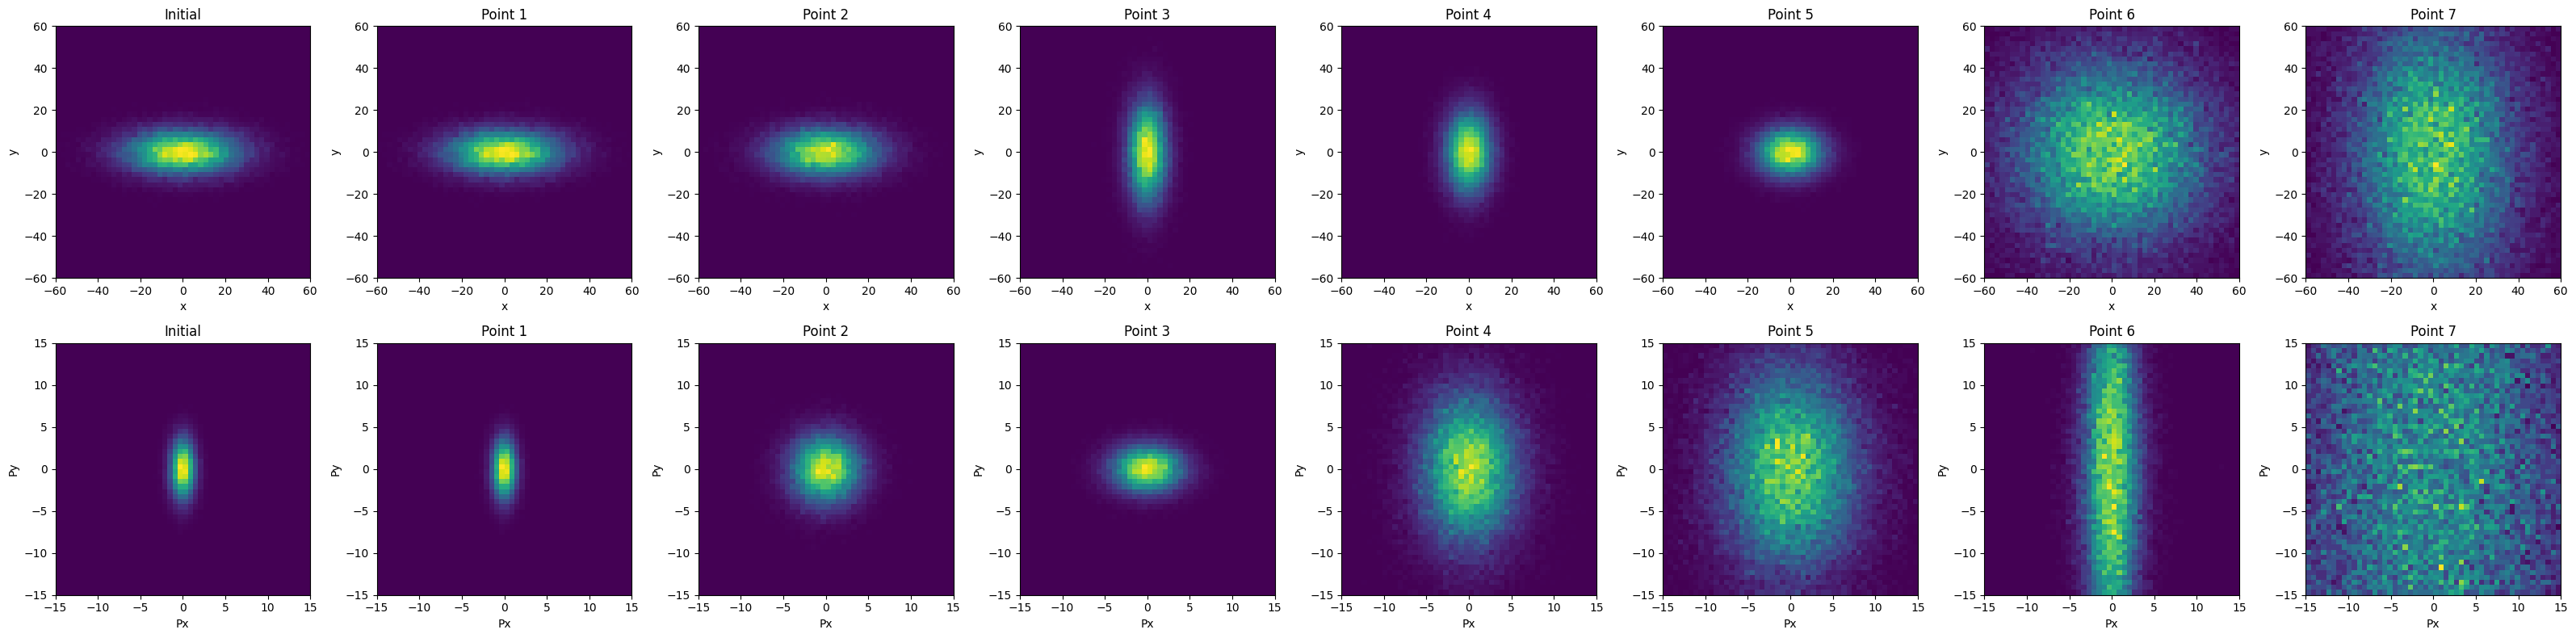

In [109]:
num_after = len(single_cell_list)
num_cols = num_after + 1  # One column for "before" and additional columns for each "after"
fig, axes = plt.subplots(2, num_cols, figsize=(4 * num_cols, 8))

x_range = [[-60, 60], [-60, 60]]
p_range = [[-15, 15], [-15, 15]]

# Plot "Before" data
axes[0, 0].hist2d(particles_before.x, particles_before.y, bins=50, range=x_range)
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].set_title("Initial")

axes[1, 0].hist2d(particles_before.Px, particles_before.Py, bins=50, range=p_range)
axes[1, 0].set_xlabel("Px")
axes[1, 0].set_ylabel("Py")
axes[1, 0].set_title("Initial")

# Plot each "After" dataset
for i, particles_after in enumerate(single_cell_list):
    col = i + 1  # Column index shifts right
    axes[0, col].hist2d(particles_after.x, particles_after.y, bins=50, range=x_range)
    axes[0, col].set_xlabel("x")
    axes[0, col].set_ylabel("y")
    axes[0, col].set_title(f"Point {i+1}")

    axes[1, col].hist2d(particles_after.Px, particles_after.Py, bins=50, range=p_range)
    axes[1, col].set_xlabel("Px")
    axes[1, col].set_ylabel("Py")
    axes[1, col].set_title(f"Point {i+1}")

plt.tight_layout()
plt.savefig("visuals/drift/test_cell_2.png")


In [14]:
z_list = [df.z[0] for df in single_cell_list]
particles_list = single_cell_list

single_data = list()
for z, df in zip(z_list, particles_list):
    (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
    single_data.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit, len(df)])
single_data = pd.DataFrame(single_data, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit", "N"])
single_data.z *= 0.001

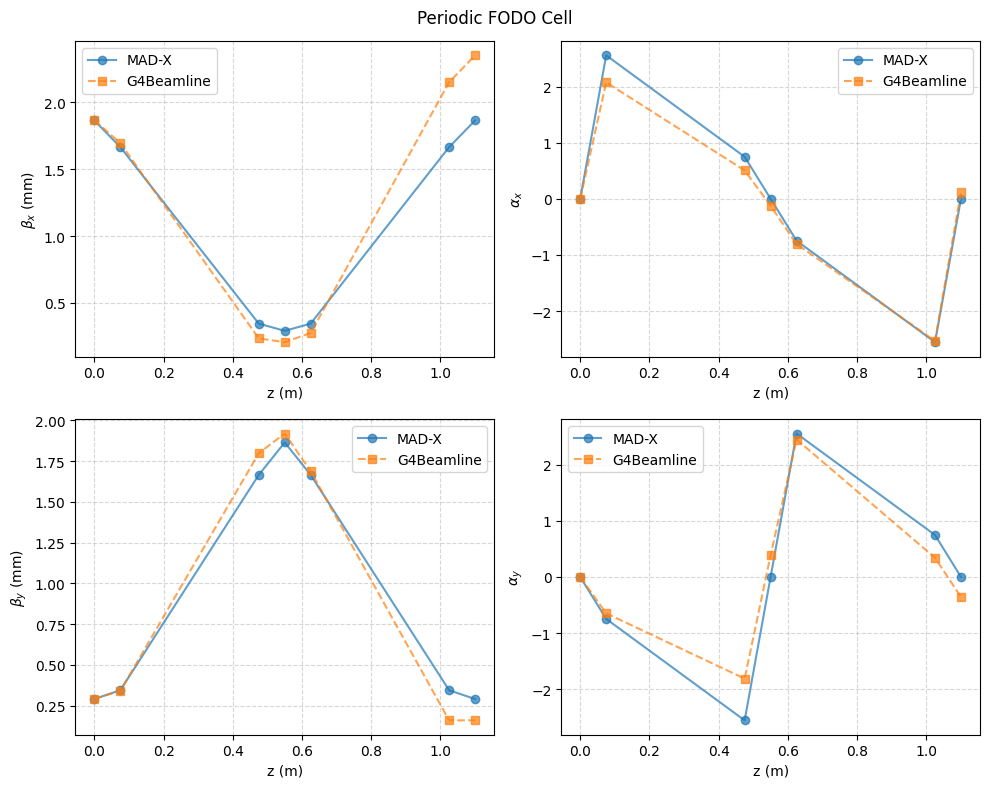

In [15]:
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Periodic FODO Cell")

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(madx_data["z"], madx_data[col], label="MAD-X", marker='o', linestyle='-', alpha=0.7)
    ax.plot(single_data["z"], single_data[col], label="G4Beamline", marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to fit title
# plt.savefig("visuals/drift/cell_compare_2.png")
plt.show()

# Comparison of different gradients

Compare the G4Beamline results for different gradients and show it on the same graph

The latest run of this experiment is with the gradient from optimization; this is stored in `optimized grad comparison.png`

In [13]:
# Generate a distribution for testing, matching the periodic segment of Ryan's MAD-X file

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)

In [5]:
def df_list_to_table(particles_list):
    z_list = [df.z[0] for df in particles_list]
    res = list()
    for z, df in zip(z_list, particles_list):
        (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
        res.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit, len(df)])
    res = pd.DataFrame(res, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit", "N"])
    res.z *= 0.001
    return res

In [17]:
test_grads = [6.6666, res.x[0]]
test_grads

[6.6666, 5.931535693359375]

In [18]:
# test_grads = [6, 6.5, 7, 7.5, 8, 8.5, 9]
df_lists = [run_g4beam(particles_before, "G4_SingleQuadTest.g4bl", 
                       multioutput=["0", "75", "475", "550", "625", "1025", "1100"], fodo_grad=x)
            for x in tqdm(test_grads)]
test_datas = [df_list_to_table(x) for x in df_lists]

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:19<00:00,  9.85s/it]


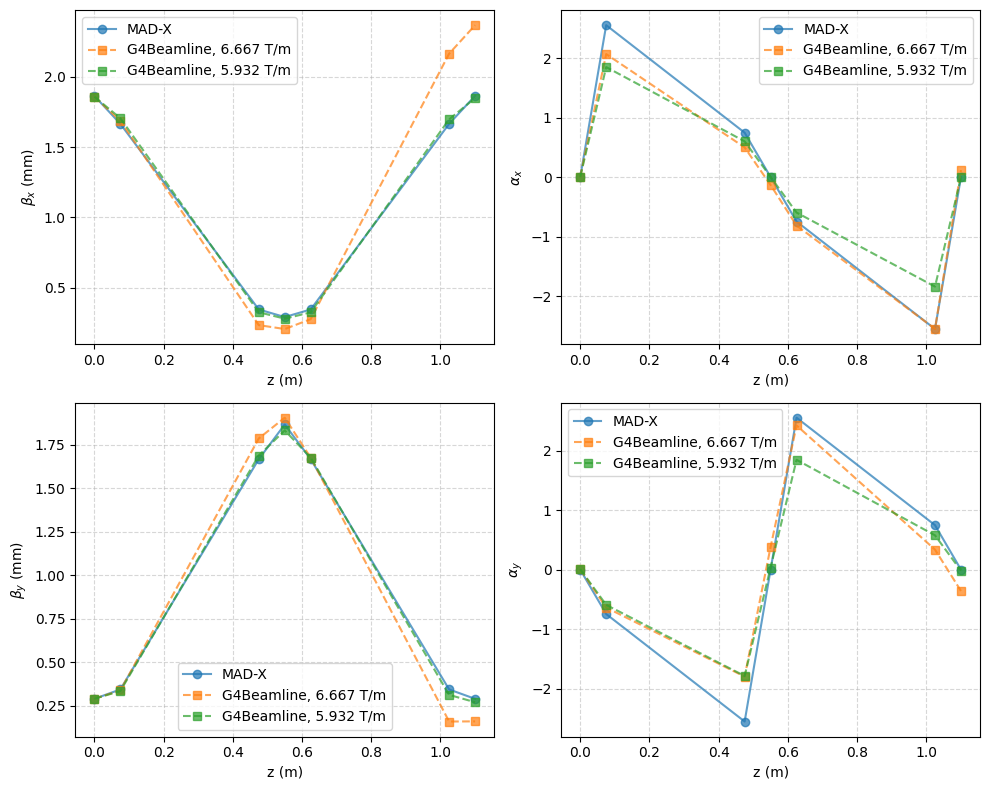

In [22]:
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# fig.suptitle("Periodic FODO Cell")

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(madx_data["z"], madx_data[col], label="MAD-X", marker='o', linestyle='-', alpha=0.7)
    for g, data in zip(test_grads[:2], test_datas[:2]):
        ax.plot(data["z"], data[col], label=f"G4Beamline, {g:.3f} T/m", marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to fit title
plt.savefig("visuals/drift/optimized grad comparison.png")
plt.show()

# Comparison of half v.s. full start and end magnet

Check if adding the half-magnets before and after the periodic cell make a difference (it seems to)

Note that this depends on cells run above (as many of these sections do)

In [36]:
df_lists = [run_g4beam(particles_before, "G4_SingleQuadTest.g4bl", 
                       multioutput=["0", "75", "475", "550", "625", "1025", "1100"], full_start=x)
            for x in [0, 1]]
test_datas = [df_list_to_table(x) for x in df_lists]

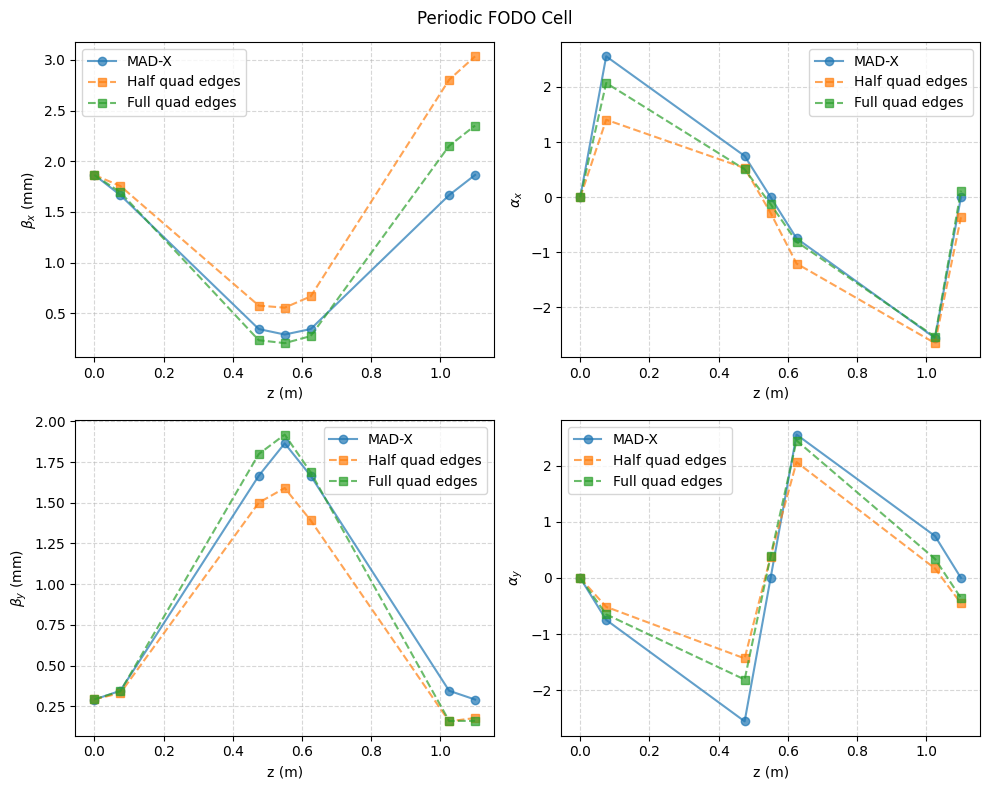

In [37]:
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Periodic FODO Cell")

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(madx_data["z"], madx_data[col], label="MAD-X", marker='o', linestyle='-', alpha=0.7)
    for label, data in zip(["Half quad edges", "Full quad edges"], test_datas):
        ax.plot(data["z"], data[col], label=label, marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to fit title
plt.savefig("visuals/drift/grad_compare_edges.png")
plt.show()

# Comparison of different `pz_std` values

Compare the channel's properties when the pz_std of the beam changes

This experiment was rerun with the optimized gradient vaue

In [3]:
# The default values, copied from above

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm

In [6]:
pz_std_list = [1, 5, 10]
particles_before_list = [
    gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)
    for pz_std in pz_std_list
]
df_lists = [run_g4beam(p, "G4_SingleQuadTest.g4bl", 
                       multioutput=["0", "75", "475", "550", "625", "1025", "1100"])
            for p in tqdm(particles_before_list)]
test_datas = [df_list_to_table(x) for x in df_lists]

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:29<00:00,  9.74s/it]


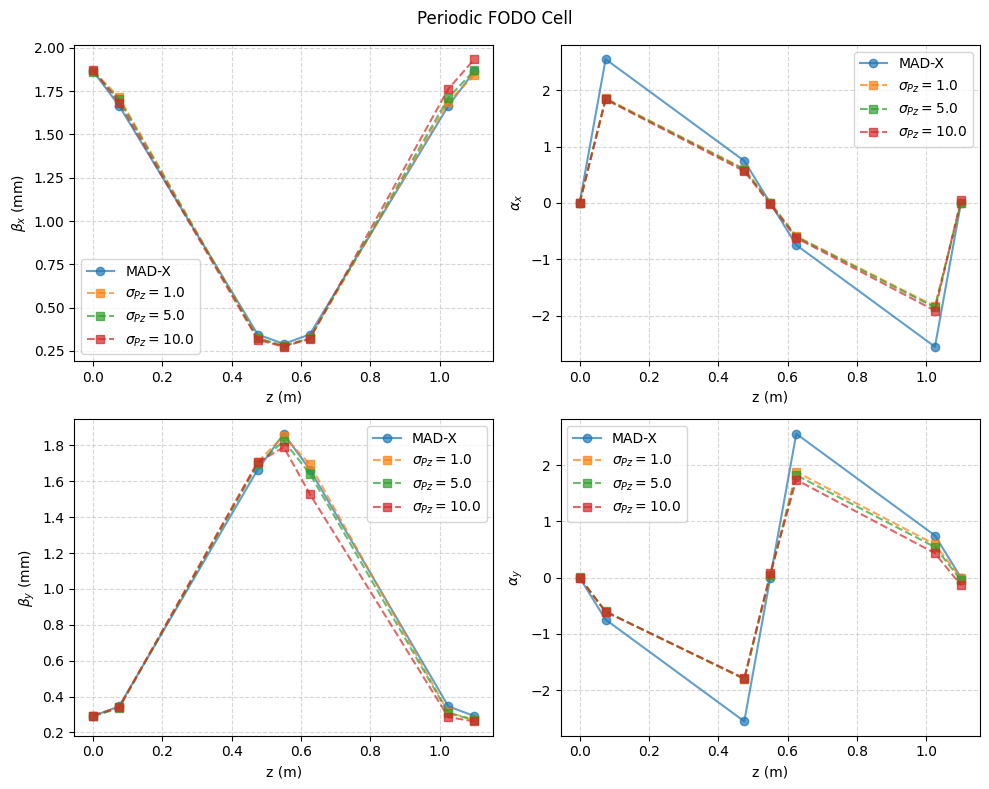

In [7]:
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Periodic FODO Cell")

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(madx_data["z"], madx_data[col], label="MAD-X", marker='o', linestyle='-', alpha=0.7)
    for pz_std, data in zip(pz_std_list, test_datas):
        ax.plot(data["z"], data[col], label=r"$\sigma_{Pz}=" + f"{pz_std:.1f}" + r"$", marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to fit title
plt.savefig("visuals/drift/grad_compare_pzstd.png")
plt.show()

# New MAD-X run and compare to G4Beamline

I made a new MAD-X file that enforces a particular starting beta and same magnet strength. I graph this output and compare it to a G4beamline run with comparable parameters

In [42]:
# Get the single-cell data from MAD-X and reformat it to match the names we're using
madx = Madx()
madx.readtable(file="./madx/fodo_periodic_test_2.tfs")
madx_data = madx.table.get('twiss').selection(columns=["name", "keyword", "s", "betx", "alfx", "bety", "alfy"], rows='all').dframe(index="name")
madx_data = madx_data.rename(columns={
    "s": "z",
    "betx": "x_beta",
    "alfx": "x_alpha",
    "bety": "y_beta",
    "alfy": "y_alpha"
})
madx_data = madx_data.iloc[[0, 2, 3, 4, 6, 7, 8]]
madx_data


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Windows)     +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2025.02.20 13:00:29      +
  ++++++++++++++++++++++++++++++++++++++++++++



,name,keyword,z,x_beta,x_alpha,y_beta,y_alpha
fodo$start,fodo$start,marker,0.000,1.782748,-4.488416e-16,0.395973,2.384471e-16
qf1h,qf1h,quadrupole,0.075,1.615676,2.153914e+00,0.451007,-7.577560e-01
drift_0,drift_0,drift,0.475,0.451007,7.577560e-01,1.615676,-2.153914e+00
qd1h,qd1h,quadrupole,0.550,0.395973,-3.077064e-17,1.782748,6.957466e-16
qd1h,qd1h,quadrupole,0.625,0.451007,-7.577560e-01,1.615676,2.153914e+00
drift_1,drift_1,drift,1.025,1.615676,-2.153914e+00,0.451007,7.577560e-01
qf1h,qf1h,quadrupole,1.100,1.782748,-2.490945e-16,0.395973,6.461835e-16


In [52]:
# Run G4Beamline using the parameters corresponding to this file

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.8    # m
beta_y = 0.4    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)
single_cell_list = run_g4beam(particles_before, "G4_SingleQuadTest.g4bl",
                              multioutput=["0", "75", "475", "550", "625", "1025", "1100"],
                              fodo_grad=17.5341/3) # calculated using rigidity B_rho = 1/3 T*m
single_data = df_list_to_table(single_cell_list)

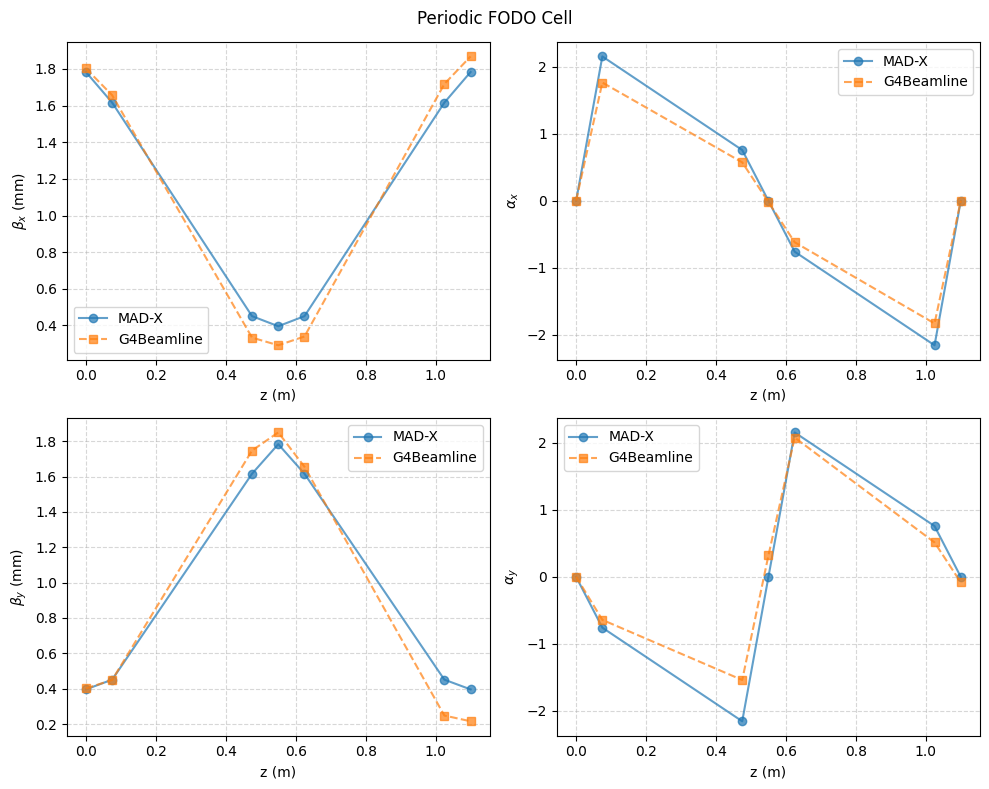

In [53]:
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Periodic FODO Cell")

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(madx_data["z"], madx_data[col], label="MAD-X", marker='o', linestyle='-', alpha=0.7)
    ax.plot(single_data["z"], single_data[col], label="G4Beamline", marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to fit title
plt.show()

# Example setup

End-to-end example showing the whole process at this point

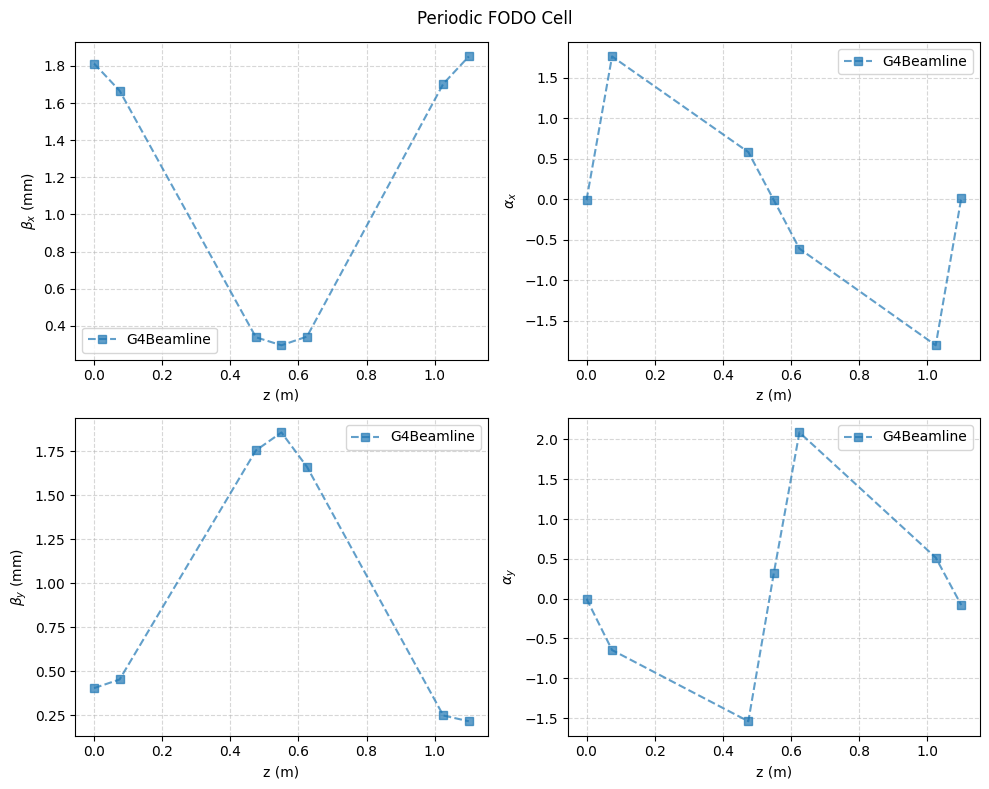

In [48]:
# Define parameters that I want
t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.8    # m
beta_y = 0.4    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

# Generate the distribution
particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)

# Run G4Beamline
single_cell_list = run_g4beam(particles_before, "G4_SingleQuadTest.g4bl",
                              multioutput=["0", "75", "475", "550", "625", "1025", "1100"],
                              fodo_grad=17.5341/3) # calculated using rigidity B_rho = 1/3 T*m

# Function to process list of distributions into table
def df_list_to_table(particles_list):
    z_list = [df.z[0] for df in particles_list]
    res = list()
    for z, df in zip(z_list, particles_list):
        (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
        res.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit, len(df)])
    res = pd.DataFrame(res, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit", "N"])
    res.z *= 0.001
    return res

# Run the function above
single_data = df_list_to_table(single_cell_list)

# Graph it
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Periodic FODO Cell")
for ax, col, col_name in zip(axes.flat, columns, column_names):
    # ax.plot(madx_data["z"], madx_data[col], label="MAD-X", marker='o', linestyle='-', alpha=0.7)
    ax.plot(single_data["z"], single_data[col], label="G4Beamline", marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optimization of magnet strength

Running an optimization over the best magnet strength to get a periodic cell in G4Beamline

In [5]:
# Generate a distribution for testing, matching the periodic segment of Ryan's MAD-X file

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)

In [11]:
def func(x):
    x = x[0]
    particles_after = run_g4beam(particles_before, "G4_SingleQuadTest.g4bl", multioutput=["0", "75", "475", "550", "625", "1025", "1100"], fodo_grad=x)
    df = particles_after[-1]
    (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
    return (x_beta - beta_x)**2 + (y_beta - beta_y)**2

res = minimize(func, 6.666, method="Nelder-Mead", bounds=((5, 8),))

iter value
  15 5.02572e-04


In [12]:
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0005025720655426731
             x: [ 5.932e+00]
           nit: 15
          nfev: 30
 final_simplex: (array([[ 5.932e+00],
                       [ 5.932e+00]]), array([ 5.026e-04,  5.026e-04]))

In [23]:
write_trackfile(particles_before, "quadtest_particles_before.txt")

# Run on the full distance

Connecting several cells together to do a test of something like the full drift channel

In [2]:
# Generate a distribution for testing, matching the periodic segment of Ryan's MAD-X file

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)

In [3]:
particles_after = run_g4beam(particles_before, "G4_QuadTest.g4bl")

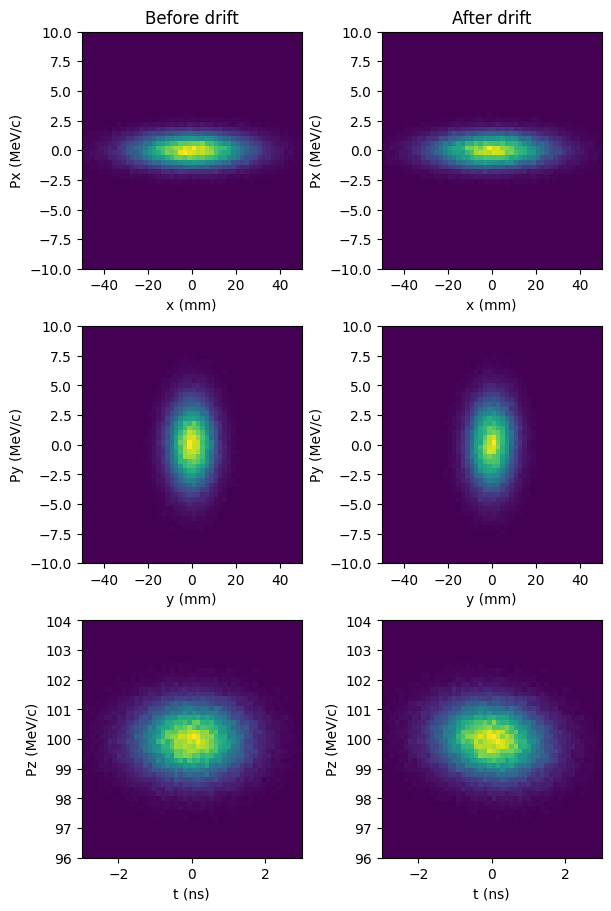

In [14]:
# Make some phase space plots
PLOT_TARGETS = [particles_before, recenter_t(particles_after)]
PLOT_TITLES = ["Before drift", "After drift"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-50, 50], [-10, 10]]
L_RANGES = [[-3, 3], [96, 104]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(6, 9)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

plt.savefig("visuals/drift/multi cell phase space vertical.png")

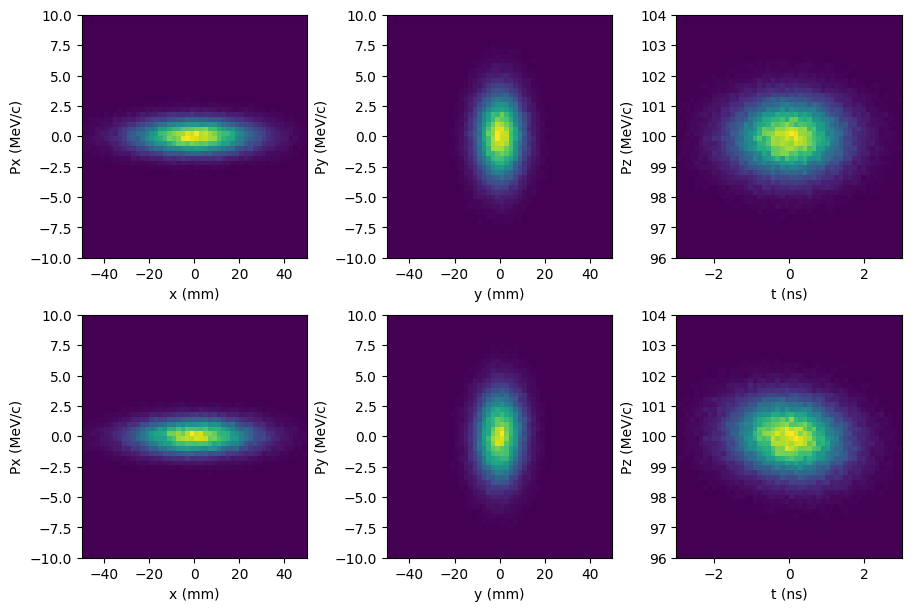

In [12]:
# Make some phase space plots
PLOT_TARGETS = [particles_before, recenter_t(particles_after)]
PLOT_TITLES = ["Before drift", "After drift"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-50, 50], [-10, 10]]
L_RANGES = [[-3, 3], [96, 104]]

fig, axes = plt.subplots(ncols = len(PLOT_AXES), nrows = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(9, 6)
for i, df in enumerate(PLOT_TARGETS):
    # axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[i][j]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

plt.savefig("visuals/drift/multi cell phase space.png")

## Try with higher pz_std

Using a different variable name in case I want to revisit both plots

In [5]:
# Generate a distribution for testing, matching the periodic segment of Ryan's MAD-X file

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1*6      # mm
pz_std = 0.8*6

particles_before_2 = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=100000)

In [6]:
particles_after_2 = run_g4beam(particles_before_2, "G4_QuadTest.g4bl")

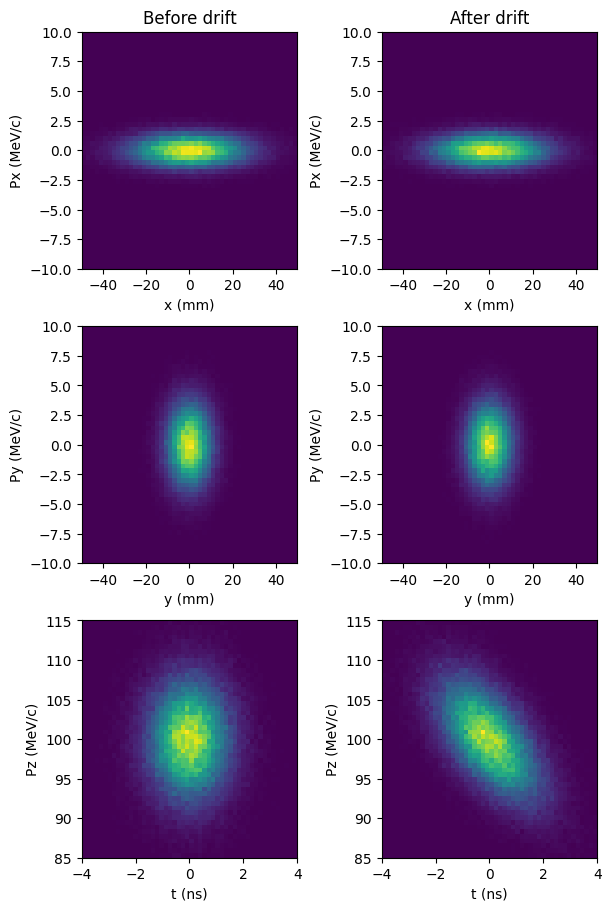

In [16]:
# Make some phase space plots
PLOT_TARGETS = [particles_before_2, recenter_t(particles_after_2)]
PLOT_TITLES = ["Before drift", "After drift"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-50, 50], [-10, 10]]
L_RANGES = [[-4, 4], [85, 115]]

fig, axes = plt.subplots(nrows = len(PLOT_AXES), ncols = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(6, 9)
for i, df in enumerate(PLOT_TARGETS):
    axes[0][i].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[j][i]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

plt.savefig("visuals/drift/multi cell phase space 2 vertical.png")

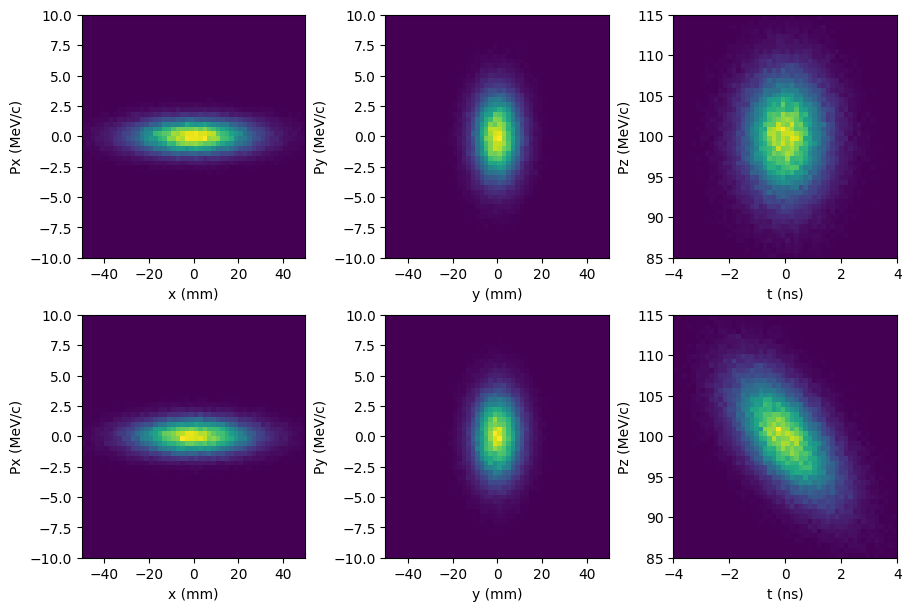

In [8]:
# Make some phase space plots
PLOT_TARGETS = [particles_before_2, recenter_t(particles_after_2)]
PLOT_TITLES = ["Before drift", "After drift"]
PLOT_AXES = [("x", "Px"), ("y", "Py"), ("t", "Pz")]
PLOT_LABELS = [("x (mm)", "Px (MeV/c)"), ("y (mm)", "Py (MeV/c)"), ("t (ns)", "Pz (MeV/c)")]
T_RANGES = [[-50, 50], [-10, 10]]
L_RANGES = [[-4, 4], [85, 115]]

fig, axes = plt.subplots(ncols = len(PLOT_AXES), nrows = len(PLOT_TARGETS), layout="constrained")
fig.set_size_inches(9, 6)
for i, df in enumerate(PLOT_TARGETS):
    # axes[i][0].set_title(PLOT_TITLES[i])
    for j, ((xaxis, yaxis), (xlabel, ylabel)) in enumerate(zip(PLOT_AXES, PLOT_LABELS)):
        ax = axes[i][j]
        ax.hist2d(df[xaxis], df[yaxis], bins=50, range=L_RANGES if j == 2 else T_RANGES)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

plt.savefig("visuals/drift/multi cell phase space 2.png")

# Test higher momentum

Quick test to run the same experiment but at 3 GeV/c. I also accidentally overwrote one graph, oh well

In [2]:
# Generate a distribution for testing, matching the periodic segment of Ryan's MAD-X file

t_emit = 0.145
momentum = 3000  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)

In [4]:
single_cell_list = run_g4beam(particles_before, "G4_SingleQuadTest.g4bl", fodo_grad=200,
                              multioutput=["0", "75", "475", "550", "625", "1025", "1100"])

In [ ]:
# Function to process list of distributions into table
def df_list_to_table(particles_list):
    z_list = [df.z[0] for df in particles_list]
    res = list()
    for z, df in zip(z_list, particles_list):
        (x_emit, x_beta, _, x_alpha, x_d, x_Dd), (y_emit, y_beta, _, y_alpha, y_d, y_Dd), z_emit = calc_all_params(cut_outliers(df))
        res.append([z, x_emit, x_beta, x_alpha, x_d, x_Dd, y_emit, y_beta, y_alpha, y_d, y_Dd, z_emit, len(df)])
    res = pd.DataFrame(res, columns=["z", "x_emit", "x_beta", "x_alpha", "x_d", "x_Dd", "y_emit", "y_beta", "y_alpha", "y_d", "y_Dd", "z_emit", "N"])
    res.z *= 0.001
    return res

In [ ]:
# Run the function above
single_data = df_list_to_table(single_cell_list)

In [6]:
single_data

,z,x_emit,x_beta,x_alpha,x_d,x_Dd,y_emit,y_beta,y_alpha,y_d,y_Dd,z_emit,N
0,0.000,0.144911,1.853337,0.002515,0.017300,0.014624,0.145521,0.290135,0.003083,-0.031346,-0.016347,0.994071,50000
1,0.075,0.144911,1.683046,2.057466,0.013438,-0.000948,0.145461,0.338143,-0.640360,-0.034385,-0.056834,0.995519,50000
2,0.475,0.145011,0.236215,0.502384,0.010856,-0.004665,0.145487,1.787397,-1.812366,-0.066672,-0.042874,0.995835,50000
3,0.550,0.144983,0.207723,-0.126945,0.012376,0.008199,0.145499,1.910247,0.364377,-0.066193,0.039069,0.994892,50000
4,0.625,0.145012,0.276732,-0.804196,0.012568,0.021292,0.145565,1.684808,2.414409,-0.060190,0.115858,0.997396,50000
5,1.025,0.145009,2.140618,-2.522331,0.020614,0.011097,0.145513,0.165920,0.361440,-0.000543,0.148591,0.998184,49999
6,1.100,0.145008,2.340675,0.108147,0.019432,-0.013457,0.145448,0.162524,-0.325302,0.011043,0.150830,0.997145,49998


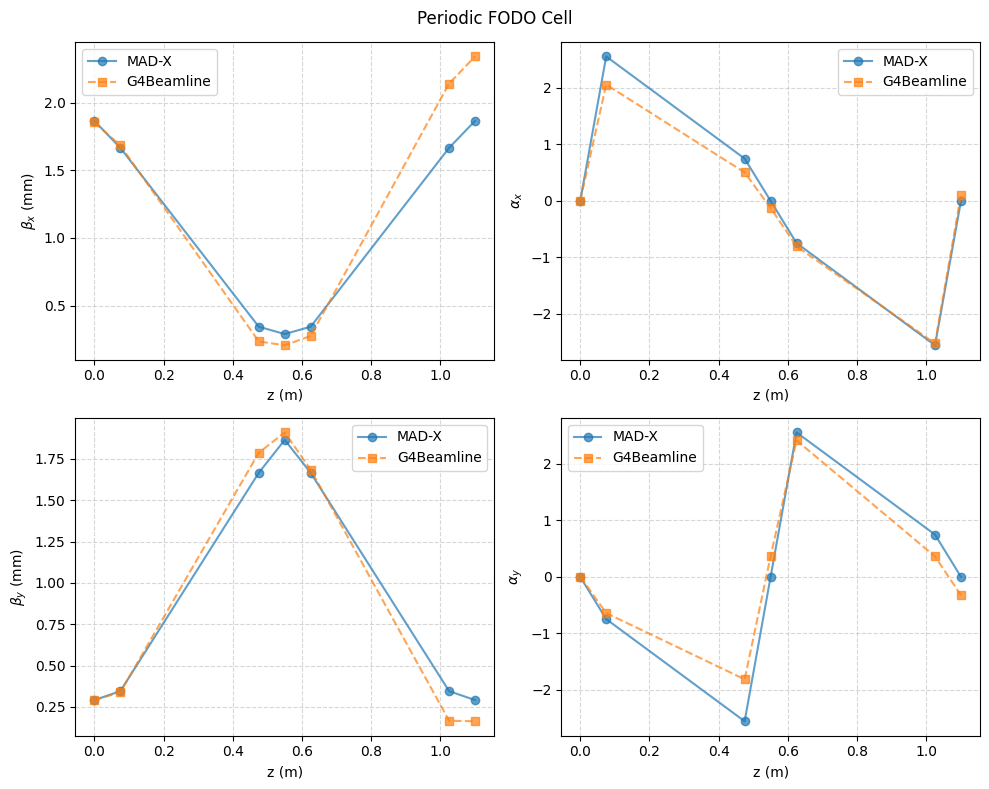

In [7]:
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Periodic FODO Cell")

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(madx_data["z"], madx_data[col], label="MAD-X", marker='o', linestyle='-', alpha=0.7)
    ax.plot(single_data["z"], single_data[col], label="G4Beamline", marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to fit title
# plt.savefig("visuals/drift/cell_compare_2.png")
plt.show()

# Test of varying step size

Critical note: to the best of my knowledge, G4Beamline **ignores** attempts to set the maxStep parameter in the file (with the "param" command). It *only* changes the maxStep if it is given as an argument when you run the command

Now that I actually know how to vary the step size, I can test its effects

In [4]:
# The default values, copied from above

t_emit = 0.145
momentum = 100  # MeV/c
beta_x = 1.865    # m
beta_y = 0.2908    # m
alpha = 0     # dimensionless
l_emit = 1      # mm
pz_std = 0.8

In [5]:
step_size_list = [1.0, 0.5, 0.1, 0.05]
particles_before = gen_distribution((beta_x, alpha, t_emit, 0, 0), (beta_y, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=12000)
df_lists = [run_g4beam(particles_before, "G4_SingleQuadTest.g4bl",
                       maxStep=s,
                       multioutput=["0", "75", "475", "550", "625", "1025", "1100"])
            for s in tqdm(step_size_list)]

100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [22:24<00:00, 336.10s/it]


In [6]:
test_datas = [df_list_to_table(x) for x in df_lists]

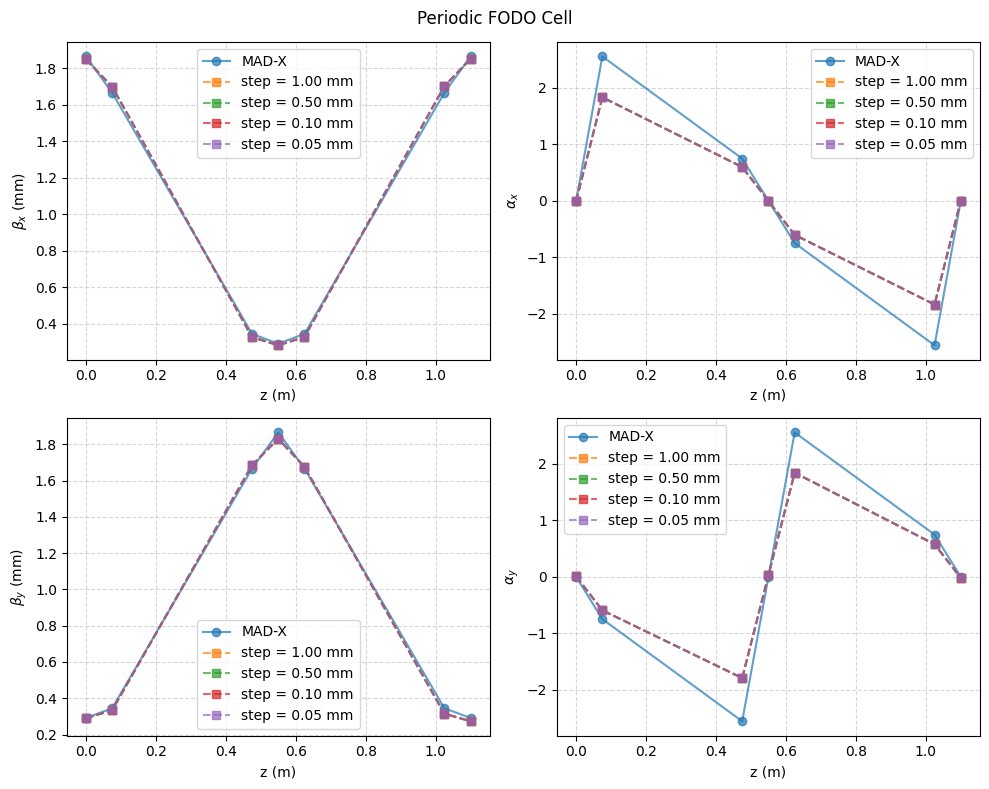

In [7]:
columns = ["x_beta", "x_alpha", "y_beta", "y_alpha"]
column_names = [r"$\beta_x$ (mm)", r"$\alpha_x$", r"$\beta_y$ (mm)", r"$\alpha_y$"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Periodic FODO Cell")

for ax, col, col_name in zip(axes.flat, columns, column_names):
    ax.plot(madx_data["z"], madx_data[col], label="MAD-X", marker='o', linestyle='-', alpha=0.7)
    for s, data in zip(step_size_list, test_datas):
        ax.plot(data["z"], data[col], label=f"step = {s:.2f} mm", marker='s', linestyle='--', alpha=0.7)
    ax.set_xlabel("z (m)")
    ax.set_ylabel(col_name)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to fit title
plt.savefig("visuals/drift/compare_step_size.png")
plt.show()